In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#1

df = pd.read_csv("C:/Users/Дмитрий/Documents/Python/4 Итоговая работа Python/HR.csv")

In [3]:
#2

df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [4]:
#3

df[['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company']].corr()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000


Axes(0.125,0.11;0.62x0.77)


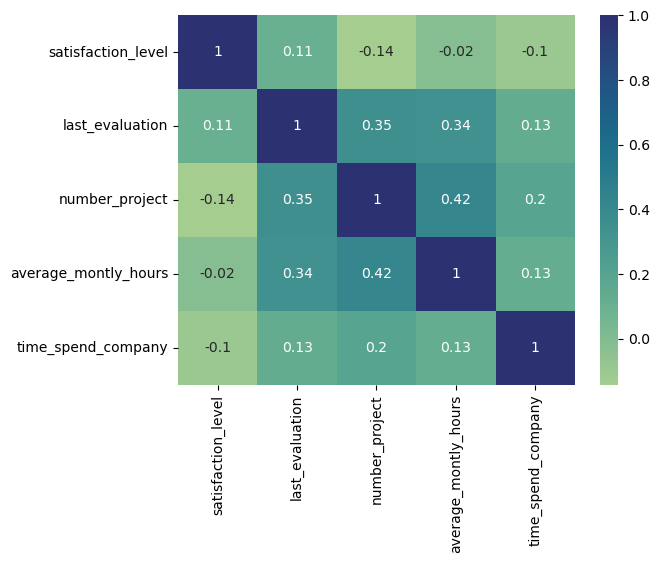

In [5]:
print(sns.heatmap(df[['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company']].corr(), annot=True, cmap='crest'))

In [6]:
print(np.corrcoef(df['number_project'], df['average_montly_hours'])[0, 1])

0.4172106344017768


<Axes: >

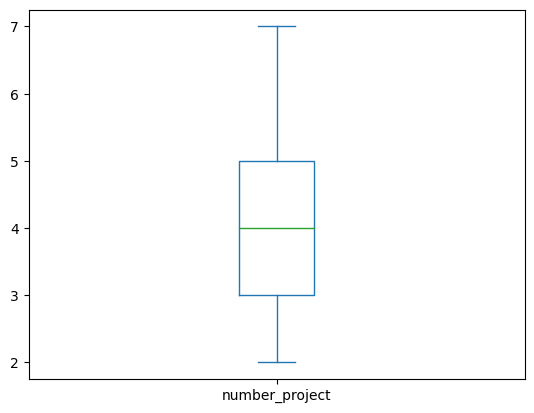

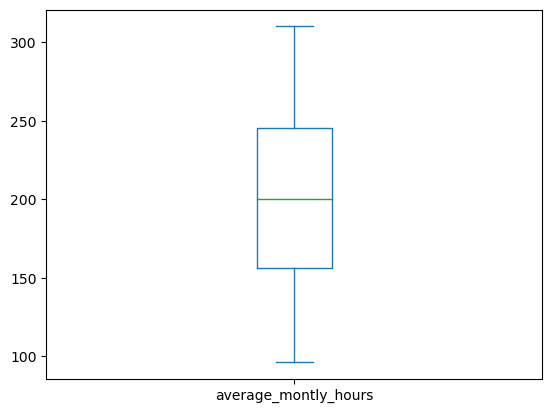

In [7]:
df[['number_project']].plot(kind='box')

df[['average_montly_hours']].plot(kind='box')

-0.02004811321947298


<Axes: xlabel='average_montly_hours', ylabel='satisfaction_level'>

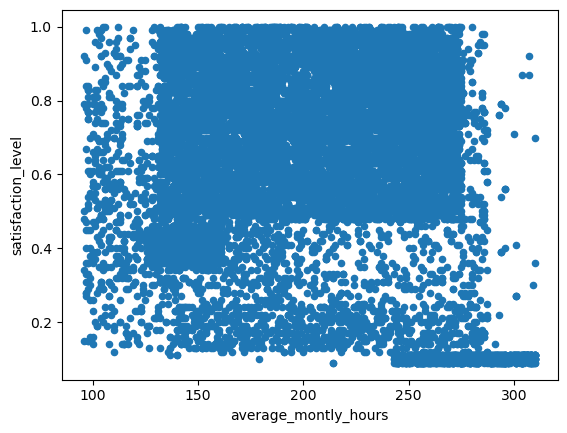

In [8]:
"""Наименьшая корелляция"""
print(np.corrcoef(df['average_montly_hours'], df['satisfaction_level'])[0, 1])

df.plot(kind='scatter', x='average_montly_hours', y='satisfaction_level')

In [9]:
#4

df.groupby('department')['department'].count()

department
IT             1227
RandD           787
accounting      767
hr              739
management      630
marketing       858
product_mng     902
sales          4140
support        2229
technical      2720
Name: department, dtype: int64

In [10]:
#5

df.groupby('salary')['department'].count()

salary
high      1237
low       7316
medium    6446
Name: department, dtype: int64

In [11]:
#6

df.groupby(['salary', 'department'])['department'].count()

salary  department 
high    IT               83
        RandD            51
        accounting       74
        hr               45
        management      225
        marketing        80
        product_mng      68
        sales           269
        support         141
        technical       201
low     IT              609
        RandD           364
        accounting      358
        hr              335
        management      180
        marketing       402
        product_mng     451
        sales          2099
        support        1146
        technical      1372
medium  IT              535
        RandD           372
        accounting      335
        hr              359
        management      225
        marketing       376
        product_mng     383
        sales          1772
        support         942
        technical      1147
Name: department, dtype: int64

0.46610234782779036
Не отклоняем нулевую гипотезу, средние, вероятно, одинаковые


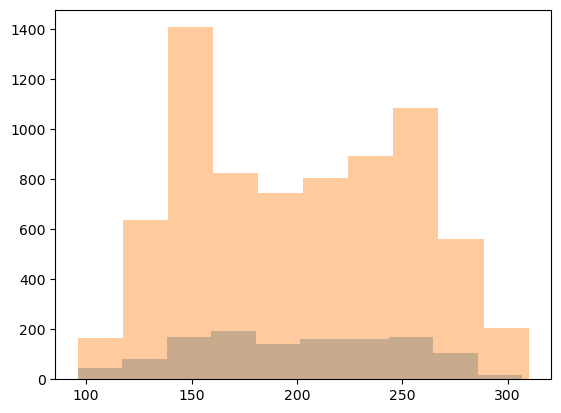

Средняе время у df_high 199.86742118027485, а у df_low 200.9965828321487. Но в абсолютной сумме времени, конечно же, больше у сотрудников с низкой зп, т.к. их просто больше


In [12]:
#7

from scipy.stats import f_oneway 
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
import scipy.stats as stats

df_high = df[df['salary'] == 'high']
df_low = df[df['salary'] == 'low']

fvalue, pvalue = stats.f_oneway(df_high['average_montly_hours'], df_low['average_montly_hours'])

print(pvalue)
if pvalue > 0.05:
    print('Не отклоняем нулевую гипотезу, средние, вероятно, одинаковые')
else:
    print('Отклоняем нулевую гипотезу, средние, вероятно, различаются')
plt.hist(df_high['average_montly_hours'], alpha  = 0.4)
plt.hist(df_low['average_montly_hours'], alpha  = 0.4)
plt.show()
print(f"Средняе время у df_high {df_high['average_montly_hours'].mean()}, а у df_low {df_low['average_montly_hours'].mean()}. Но в абсолютной сумме времени, конечно же, больше у сотрудников с низкой зп, т.к. их просто больше")

In [13]:
#8

hr_work = df[df['left'] == 0]
hr_dism = df[df['left'] == 1]

print(f"Доля сотрудников с повышением за последние 5 лет среди не уволившихся сотрудников {hr_work[hr_work['promotion_last_5years'].isin(['promotion_last_5years', 1])]['promotion_last_5years'].count()/df['promotion_last_5years'].count(): .0%}")
print(f"Доля сотрудников с повышением за последние 5 лет среди уволившихся сотрудников {hr_dism[hr_dism['promotion_last_5years'].isin(['promotion_last_5years', 1])]['promotion_last_5years'].count()/df['promotion_last_5years'].count(): .0%}")
print('😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁')
print(f"Средняя степень удовлетворенности среди не уволившихся сотрудников {hr_work['satisfaction_level'].mean(): .2f}")
print(f"Средняя степень удовлетворенности среди уволившихся сотрудников {hr_dism['satisfaction_level'].mean(): .2f}")
print('😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁')
print(f"Среднее количество проектов среди не уволившихся сотрудников {hr_work['number_project'].mean(): .2f}")
print(f"Среднее количество проектов среди уволившихся сотрудников {hr_dism['number_project'].mean(): .2f}")

Доля сотрудников с повышением за последние 5 лет среди не уволившихся сотрудников  2%
Доля сотрудников с повышением за последние 5 лет среди уволившихся сотрудников  0%
😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁
Средняя степень удовлетворенности среди не уволившихся сотрудников  0.67
Средняя степень удовлетворенности среди уволившихся сотрудников  0.44
😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁😁
Среднее количество проектов среди не уволившихся сотрудников  3.79
Среднее количество проектов среди уволившихся сотрудников  3.86


In [14]:
#9

df_lda = df.iloc[:, :-2]
df_lda_left = np.array(df_lda['left'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_lda, df_lda_left)

In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [16]:
lda.predict(X_test)

array([1, 1, 0, ..., 0, 0, 0], dtype=int64)

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, lda.predict(X_test))

0.7674666666666666